# Download PHOENIX + ATLAS Models with Padova Isochrone Normalization

This notebook:
1. Downloads **PHOENIX models** for 3800-10000K (Göttingen server)
2. Downloads **ATLAS9 models** for 10000-15000K (STScI)
3. Uses Padova isochrones to get stellar radii AND masses
4. Normalizes all models to flux at 10 pc (matching PoWR convention)
5. Filters PoWR models to only include those with valid isochrone coverage
6. Saves in unified PoWR-compatible format

## Coverage:
- **PHOENIX**: 3800-10000K (K through late B stars)
- **ATLAS**: 10000-15000K (late B through early B stars)
- **PoWR**: 15000-50000K (filtered to isochrone coverage)
- **Combined**: 3800-50000K complete coverage

## Output Format:
- 2-column ASCII: wavelength (Å), log₁₀(flux at 10pc in erg/s/cm²/Å)
- Filename: `atlas-or-phoenix-TTT-GG.txt`
- Directory: `./stellar_models/`
- Model manifest CSV with (Teff, logg, logL, Mass, R) for all valid models

## Step 1: Import Libraries

In [14]:
import numpy as np
import urllib.request
import requests
from io import BytesIO
from pathlib import Path
from astropy.io import fits
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Configuration

In [9]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# PHOENIX models (cooler stars: 3800-10000K)
# Extended down to 3800K to cover K-type stars
PHOENIX_TEFF_VALUES = [3800, 4000, 4200, 4400, 4600, 4800, 5000, 5200, 5400, 5600, 5800, 
                       6000, 6200, 6400, 6600, 6800, 7000, 7200, 7400, 7600, 7800, 
                       8000, 8200, 8400, 8600, 8800, 9000, 9200, 9400, 9600, 9800, 10000]  # K

# ATLAS models (hotter stars: 10000-15000K) 
ATLAS_TEFF_VALUES = [10000, 10500, 11000, 12000, 13000, 14000, 15000]  # K

# Combine all temperatures
ALL_TEFF_VALUES = sorted(set(PHOENIX_TEFF_VALUES + ATLAS_TEFF_VALUES))

LOGG_VALUES = [2.0, 2.5, 3.0, 3.5, 4.0, 4.5]  # dex
METALLICITY = 0.0  # [M/H] = 0 (solar)

# Wavelength range (Gaia BP/RP coverage)
LAMBDA_MIN = 3300.0  # Å
LAMBDA_MAX = 10500.0  # Å

# Directories
FITS_DIR = Path('./atlas_fits')  # Downloaded ATLAS FITS files
PHOENIX_DIR = Path('./phoenix_fits')  # Downloaded PHOENIX files
OUTPUT_DIR = Path('./stellar_models')  # Final output models (both types)
POWR_MODEL_DIR = Path('./griddl-gal-ob-vd3-line_calib')  # Pre-downloaded PoWR models
ISOCHRONE_FILE = 'Padova_isochrones.fits'  # Isochrone table
MODEL_MANIFEST_FILE = 'model_manifest.csv'  # Output: list of all valid models

FITS_DIR.mkdir(exist_ok=True)
PHOENIX_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# Model sources
STSCI_BASE = "https://archive.stsci.edu/hlsps/reference-atlases/cdbs/grid/ck04models/"
PHOENIX_BASE = "https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/HiResFITS/PHOENIX-ACES-AGSS-COND-2011/"
PHOENIX_WAVE_URL = "https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/HiResFITS/WAVE_PHOENIX-ACES-AGSS-COND-2011.fits"

# PHOENIX grid points available on Göttingen server
# Extended to include cooler temperatures (2300K-12000K available)
PHOENIX_MODEL_TEMPS = np.arange(2300, 12200, 100)  # 100K steps below 7000K, 200K above
PHOENIX_MODEL_LOGG = np.arange(0, 6.5, 0.5)

# Isochrone matching tolerances (for PoWR filtering)
ISOCHRONE_TEFF_TOLERANCE = 0.05  # 5% in Teff
ISOCHRONE_LOGG_TOLERANCE = 0.25   # 0.5 dex in log g

# Physical constants (CGS)
DISTANCE_10PC = 10.0 * 3.086e18  # 10 pc in cm
LSUN = 3.828e33  # Solar luminosity in erg/s
SIGMA_SB = 5.67e-5  # Stefan-Boltzmann constant in erg/cm²/s/K⁴

print(f"Configuration:")
print(f"  PHOENIX: {len(PHOENIX_TEFF_VALUES)} temps ({min(PHOENIX_TEFF_VALUES)}-{max(PHOENIX_TEFF_VALUES)}K)")
print(f"  ATLAS: {len(ATLAS_TEFF_VALUES)} temps ({min(ATLAS_TEFF_VALUES)}-{max(ATLAS_TEFF_VALUES)}K)")
print(f"  Combined: {len(ALL_TEFF_VALUES)} unique temps ({min(ALL_TEFF_VALUES)}-{max(ALL_TEFF_VALUES)}K)")
print(f"  log g: {len(LOGG_VALUES)} values ({min(LOGG_VALUES)}-{max(LOGG_VALUES)})")
print(f"  Total PHOENIX+ATLAS models: {len(ALL_TEFF_VALUES) * len(LOGG_VALUES)}")
print(f"  Isochrone file: {ISOCHRONE_FILE}")
print(f"  PoWR model dir: {POWR_MODEL_DIR}")
print(f"  Output: {OUTPUT_DIR.absolute()}")

Configuration:
  PHOENIX: 32 temps (3800-10000K)
  ATLAS: 7 temps (10000-15000K)
  Combined: 38 unique temps (3800-15000K)
  log g: 6 values (2.0-4.5)
  Total PHOENIX+ATLAS models: 228
  Isochrone file: Padova_isochrones.fits
  PoWR model dir: griddl-gal-ob-vd3-line_calib
  Output: /Users/rix/Science/Projects/GAIA/GaiaDR3/BP-RP/All-Sky/HotStars_XP/stellar_models


## Step 3: Load Padova Isochrones

In [ ]:
# ============================================================================
# LOAD PADOVA ISOCHRONES
# ============================================================================

print(f"\nLoading Padova isochrones from {ISOCHRONE_FILE}...")

try:
    with fits.open(ISOCHRONE_FILE) as hdul:
        iso_data = hdul[1].data
        
        # Extract columns as COPIES (not views)
        iso_logTe = np.array(iso_data['logTe'], dtype=float).copy()
        iso_logg = np.array(iso_data['logg'], dtype=float).copy()
        iso_logL = np.array(iso_data['logL'], dtype=float).copy()
        iso_Mass = np.array(iso_data['Mass'], dtype=float).copy()  # Current mass (not Mini)
        iso_logAge = np.array(iso_data['logAge'], dtype=float).copy()  # log(age/years)
        
        # Force 1D if needed
        if iso_logTe.ndim == 0:
            iso_logTe = np.array([iso_logTe])
            iso_logg = np.array([iso_logg])
            iso_logL = np.array([iso_logL])
            iso_Mass = np.array([iso_Mass])
            iso_logAge = np.array([iso_logAge])
        
        print(f"  Loaded {len(iso_logTe)} isochrone points")
        print(f"  logTe range: {iso_logTe.min():.3f} - {iso_logTe.max():.3f}")
        print(f"     (Teff range: {10**iso_logTe.min():.0f} - {10**iso_logTe.max():.0f} K)")
        print(f"  logg range: {iso_logg.min():.2f} - {iso_logg.max():.2f}")
        print(f"  logL range: {iso_logL.min():.2f} - {iso_logL.max():.2f}")
        print(f"  Mass range: {iso_Mass.min():.2f} - {iso_Mass.max():.2f} M_sun")
        print(f"  logAge range: {iso_logAge.min():.2f} - {iso_logAge.max():.2f} (age: {10**(iso_logAge.min()-6):.1f} - {10**(iso_logAge.max()-6):.1f} Myr)")
        
except Exception as e:
    print(f"\n✗ ERROR: Could not load {ISOCHRONE_FILE}")
    print(f"  {e}")
    raise

## Step 4: Helper Functions

In [ ]:
# ============================================================================
# HELPER FUNCTIONS (Isochrones + Scaling)
# ============================================================================

def find_nearest_isochrone(Teff, logg, iso_logTe, iso_logg, iso_logL, iso_Mass, iso_logAge=None):
    """
    Find nearest match in isochrone table and return logL, Mass, logAge, and their variances.
    
    Parameters
    ----------
    Teff : float
        Target effective temperature (K)
    logg : float
        Target surface gravity
    iso_logTe, iso_logg, iso_logL, iso_Mass : arrays
        Isochrone table columns
    iso_logAge : array, optional
        Isochrone ages (log10(age/years))
    
    Returns
    -------
    dict with keys:
        logL, Mass, logAge : best-match values
        logL_std, Mass_std, logAge_std : standard deviation from nearby points
        matched_Teff, matched_logg : actual isochrone values at best match
        min_distance : normalized distance to nearest point
    """
    logTe_target = np.log10(Teff)
    
    # Normalization for distance calculation
    dlogTe_norm = 0.1   # ~25% in Teff
    dlogg_norm = 0.5    # 0.5 dex
    
    # Calculate normalized distance to all isochrone points
    distance = ((iso_logTe - logTe_target) / dlogTe_norm)**2 + \
               ((iso_logg - logg) / dlogg_norm)**2
    
    # Best match
    idx = np.argmin(distance)
    min_distance = np.sqrt(distance[idx])
    
    matched_logTe = iso_logTe[idx]
    matched_logg = iso_logg[idx]
    matched_logL = iso_logL[idx]
    matched_Mass = iso_Mass[idx]
    matched_logAge = iso_logAge[idx] if iso_logAge is not None else np.nan
    
    # Estimate variance from nearby points (within 2x the best distance, minimum 5 points)
    threshold = max(2.0 * min_distance, 1.0)  # At least distance=1
    nearby_mask = distance < threshold**2
    
    if nearby_mask.sum() >= 3:
        logL_std = np.std(iso_logL[nearby_mask])
        Mass_std = np.std(iso_Mass[nearby_mask])
        logAge_std = np.std(iso_logAge[nearby_mask]) if iso_logAge is not None else np.nan
    else:
        # Not enough nearby points - use a default uncertainty
        logL_std = 0.2  # ~0.2 dex
        Mass_std = 0.1 * matched_Mass  # 10% relative
        logAge_std = 0.5  # 0.5 dex default for age
    
    return {
        'logL': matched_logL,
        'Mass': matched_Mass,
        'logAge': matched_logAge,
        'logL_std': logL_std,
        'Mass_std': Mass_std,
        'logAge_std': logAge_std,
        'matched_Teff': 10**matched_logTe,
        'matched_logg': matched_logg,
        'min_distance': min_distance
    }


def has_isochrone_coverage(Teff, logg, iso_logTe, iso_logg, 
                            teff_tol=ISOCHRONE_TEFF_TOLERANCE, 
                            logg_tol=ISOCHRONE_LOGG_TOLERANCE):
    """
    Check if (Teff, logg) has isochrone coverage within tolerances.
    
    Parameters
    ----------
    Teff : float
        Effective temperature (K)
    logg : float
        Surface gravity
    iso_logTe, iso_logg : arrays
        Isochrone table columns
    teff_tol : float
        Fractional tolerance in Teff (default 5%)
    logg_tol : float
        Absolute tolerance in log g (default 0.5 dex)
    
    Returns
    -------
    bool : True if covered, False otherwise
    """
    logTe_target = np.log10(Teff)
    logTe_tol = np.log10(1 + teff_tol)  # Convert fractional to log tolerance
    
    # Check if any isochrone point is within tolerances
    teff_ok = np.abs(iso_logTe - logTe_target) < logTe_tol
    logg_ok = np.abs(iso_logg - logg) < logg_tol
    
    return np.any(teff_ok & logg_ok)


def calculate_radius_from_luminosity(Teff, logL):
    """Calculate stellar radius from L and Teff using Stefan-Boltzmann"""
    L = 10**logL * LSUN  # erg/s
    R = np.sqrt(L / (4 * np.pi * SIGMA_SB * Teff**4))
    return R


def scale_to_10pc(wavelength, flux_surface, stellar_radius_cm):
    """Scale surface flux to 10 pc"""
    scaling_factor = (stellar_radius_cm / DISTANCE_10PC)**2
    flux_10pc = flux_surface * scaling_factor
    return flux_10pc


def trim_to_gaia_range(wavelength, flux):
    """Trim to Gaia wavelength range"""
    mask = (wavelength >= LAMBDA_MIN) & (wavelength <= LAMBDA_MAX)
    return wavelength[mask], flux[mask]


def save_model(wave, flux, teff, logg, model_type='atlas'):
    """Save in PoWR-compatible format"""
    tt = teff // 1000
    rem = teff % 1000
    gg = int(logg * 10)

    # Use single unified naming convention
    model_type = 'atlas-or-phoenix'
    name = f"{model_type}-{teff//100:03d}-{gg:02d}.txt"
    
    path = OUTPUT_DIR / name
    log_flux = np.log10(flux)
    
    header = f"{model_type.upper()}: Teff={teff}K, logg={logg}, [M/H]={METALLICITY}\n"
    header += f"Radius from Padova isochrones, normalized to 10pc\n"
    header += f"Wavelength (Angstrom), log10(Flux at 10pc in erg/s/cm2/A)"
    
    np.savetxt(path, np.column_stack([wave, log_flux]), 
               fmt='%12.4f %12.6f', header=header)
    
    return path

print("Helper functions defined!")
print(f"  - find_nearest_isochrone: returns logL, Mass, logAge, and uncertainties")
print(f"  - has_isochrone_coverage: checks if (Teff, logg) is covered")
print(f"  - Tolerances: {ISOCHRONE_TEFF_TOLERANCE*100:.0f}% in Teff, {ISOCHRONE_LOGG_TOLERANCE:.1f} dex in log g")

## Step 5: PHOENIX Download Functions

In [5]:
# ============================================================================
# PHOENIX-SPECIFIC FUNCTIONS
# ============================================================================

def get_phoenix_url(T_eff, log_g, Z=0.0):
    """Construct PHOENIX model URL"""
    closest_temp = PHOENIX_MODEL_TEMPS[np.argmin(np.abs(PHOENIX_MODEL_TEMPS - T_eff))]
    closest_logg = PHOENIX_MODEL_LOGG[np.argmin(np.abs(PHOENIX_MODEL_LOGG - log_g))]
    
    z_sign = '-' if Z <= 0.25 else '+'
    metallicity_term = f'{z_sign}{abs(Z):.1f}.'
    directory_term = f'Z{z_sign}{abs(Z):.1f}'
    
    url = (
        PHOENIX_BASE +
        directory_term +
        f'/lte{closest_temp:05d}-{closest_logg:.2f}' +
        metallicity_term +
        'PHOENIX-ACES-AGSS-COND-2011-HiRes.fits'
    )
    
    return url


# Download PHOENIX wavelength grid once
phoenix_wavelengths = None

def get_phoenix_wavelengths():
    """Download PHOENIX wavelength grid (once)"""
    global phoenix_wavelengths
    
    if phoenix_wavelengths is not None:
        return phoenix_wavelengths
    
    print("  Downloading PHOENIX wavelength grid...")
    response = requests.get(PHOENIX_WAVE_URL, timeout=60)
    response.raise_for_status()
    
    fits_file = fits.open(BytesIO(response.content))
    wavelengths = fits_file[0].data  # in Angstroms
    fits_file.close()
    
    phoenix_wavelengths = wavelengths
    print(f"  ✓ Got {len(wavelengths)} wavelength points")
    
    return wavelengths


def download_phoenix_spectrum(teff, logg):
    """Download PHOENIX spectrum from Göttingen"""
    url = get_phoenix_url(teff, logg, METALLICITY)
    
    response = requests.get(url, timeout=60)
    
    if response.status_code != 200:
        raise ValueError(f"HTTP {response.status_code}")
    
    fits_file = fits.open(BytesIO(response.content))
    flux = fits_file[0].data  # erg/s/cm²/cm at stellar surface
    flux = flux/1.e8  # to convert to erg/s/cm²/Å at stellar surface
    fits_file.close()
    
    wavelengths = get_phoenix_wavelengths()
    
    # Filter positive wavelengths
    mask = wavelengths > 0
    
    return wavelengths[mask], flux[mask]

print("PHOENIX functions defined!")

PHOENIX functions defined!


## Step 6: ATLAS Download Functions

In [6]:
# ============================================================================
# ATLAS-SPECIFIC FUNCTIONS
# ============================================================================

def download_atlas_fits(teff, metallicity=0.0):
    """Download ATLAS FITS file from STScI"""
    if metallicity == 0.0:
        metal_str = "p00"
    elif metallicity > 0:
        metal_str = f"p{int(abs(metallicity)*10):02d}"
    else:
        metal_str = f"m{int(abs(metallicity)*10):02d}"
    
    filename = f"ck{metal_str}_{teff:05d}.fits"
    filepath = FITS_DIR / filename
    
    if filepath.exists():
        return filepath
    
    url = STSCI_BASE + f"ck{metal_str}/{filename}"
    
    try:
        urllib.request.urlretrieve(url, filepath)
        return filepath
    except:
        return None


def read_atlas_spectrum(fits_path, logg):
    """Extract spectrum for specific log g from ATLAS FITS"""
    with fits.open(fits_path) as hdul:
        data = hdul[1].data
        
        logg_col = f"g{int(logg*10):02d}"
        
        if logg_col not in data.names:
            raise ValueError(f"log g = {logg} not available")
        
        wavelength = data['WAVELENGTH']
        flux = data[logg_col]
        
        mask = flux > 0
        
        return wavelength[mask], flux[mask]

print("ATLAS functions defined!")

ATLAS functions defined!


## Step 7: Download and Process All Models

In [ ]:
# ============================================================================
# DOWNLOAD AND PROCESS ALL MODELS
# ============================================================================

print(f"\n{'='*80}")
print("DOWNLOADING AND PROCESSING STELLAR MODELS")
print(f"{'='*80}\n")

success, failed = 0, 0
failed_list = []
model_info = []

# IMPORTANT: Store ATLAS wavelength grid for resampling PHOENIX
atlas_wavelength_grid = None

# PROCESS ATLAS FIRST to get reference wavelength grid
print("PART 1: Processing ATLAS models (to establish wavelength grid)\n")

for i, teff in enumerate(ATLAS_TEFF_VALUES, 1):
    print(f"[ATLAS {i}/{len(ATLAS_TEFF_VALUES)}] Teff = {teff}K")
    
    # Download FITS
    fits_path = download_atlas_fits(teff, METALLICITY)
    if fits_path is None:
        print(f"  ✗ FITS not available")
        for logg in LOGG_VALUES:
            failed += 1
            failed_list.append(('ATLAS', teff, logg, "FITS not available"))
        continue
    
    for logg in LOGG_VALUES:
        print(f"  logg={logg:.1f}...", end=' ', flush=True)
        
        try:
            # Find isochrone match (now returns dict with Mass and logAge)
            iso_match = find_nearest_isochrone(
                teff, logg, iso_logTe, iso_logg, iso_logL, iso_Mass, iso_logAge
            )
            logL = iso_match['logL']
            Mass = iso_match['Mass']
            Mass_std = iso_match['Mass_std']
            logAge = iso_match['logAge']
            logAge_std = iso_match['logAge_std']
            
            # Calculate radius
            R_cm = calculate_radius_from_luminosity(teff, logL)
            R_sun = R_cm / 6.96e10
            
            # Read ATLAS spectrum
            wave, flux_surf = read_atlas_spectrum(fits_path, logg)
            
            # STORE WAVELENGTH GRID (first time only)
            if atlas_wavelength_grid is None:
                atlas_wavelength_grid = wave.copy()
                print(f"\n  → Stored ATLAS wavelength grid: {len(wave)} points")
                print(f"     Range: {wave.min():.1f}-{wave.max():.1f}Å\n", end='')
            
            # Scale to 10 pc
            flux_10pc = scale_to_10pc(wave, flux_surf, R_cm)
            
            # Trim to Gaia range
            wave_gaia, flux_gaia = trim_to_gaia_range(wave, flux_10pc)
            
            if len(wave_gaia) < 100:
                raise ValueError(f"Only {len(wave_gaia)} points")
            
            # Save
            outfile = save_model(wave_gaia, flux_gaia, teff, logg, model_type='atlas')
            
            print("✓")
            success += 1
            
            model_info.append({
                'source': 'ATLAS',
                'Teff': teff,
                'logg': logg,
                'logL': logL,
                'Mass': Mass,
                'Mass_std': Mass_std,
                'logAge': logAge,
                'logAge_std': logAge_std,
                'R_Rsun': R_sun,
                'n_points': len(wave_gaia),
                'filename': outfile.name
            })
            
        except Exception as e:
            print(f"✗ {e}")
            failed += 1
            failed_list.append(('ATLAS', teff, logg, str(e)))

# NOW PROCESS PHOENIX - resampled to ATLAS grid
print(f"\n{'='*80}")
print("PART 2: Processing PHOENIX models (resampling to ATLAS grid)")
print(f"{'='*80}\n")

if atlas_wavelength_grid is None:
    print("ERROR: No ATLAS wavelength grid available! Cannot process PHOENIX.")
else:
    print(f"Target grid: {len(atlas_wavelength_grid)} wavelength points\n")
    
    for i, teff in enumerate(PHOENIX_TEFF_VALUES, 1):
        print(f"[PHOENIX {i}/{len(PHOENIX_TEFF_VALUES)}] Teff = {teff}K")
        
        for logg in LOGG_VALUES:
            print(f"  logg={logg:.1f}...", end=' ', flush=True)
            
            try:
                # Find isochrone match (now returns dict with Mass and logAge)
                iso_match = find_nearest_isochrone(
                    teff, logg, iso_logTe, iso_logg, iso_logL, iso_Mass, iso_logAge
                )
                logL = iso_match['logL']
                Mass = iso_match['Mass']
                Mass_std = iso_match['Mass_std']
                logAge = iso_match['logAge']
                logAge_std = iso_match['logAge_std']
                
                # Calculate radius
                R_cm = calculate_radius_from_luminosity(teff, logL)
                R_sun = R_cm / 6.96e10
                
                # Download high-res PHOENIX spectrum
                wave_hires, flux_surf_hires = download_phoenix_spectrum(teff, logg)
                
                # RESAMPLE TO ATLAS GRID using interpolation
                flux_surf_atlas = np.interp(atlas_wavelength_grid, wave_hires, flux_surf_hires)
                
                # Scale to 10 pc
                flux_10pc = scale_to_10pc(atlas_wavelength_grid, flux_surf_atlas, R_cm)
                
                # Trim to Gaia range
                wave_gaia, flux_gaia = trim_to_gaia_range(atlas_wavelength_grid, flux_10pc)
                
                if len(wave_gaia) < 100:
                    raise ValueError(f"Only {len(wave_gaia)} points")
                
                # Save
                outfile = save_model(wave_gaia, flux_gaia, teff, logg, model_type='phoenix')
                
                print("✓")
                success += 1
                
                model_info.append({
                    'source': 'PHOENIX',
                    'Teff': teff,
                    'logg': logg,
                    'logL': logL,
                    'Mass': Mass,
                    'Mass_std': Mass_std,
                    'logAge': logAge,
                    'logAge_std': logAge_std,
                    'R_Rsun': R_sun,
                    'n_points': len(wave_gaia),
                    'filename': outfile.name
                })
                
            except Exception as e:
                print(f"✗ {e}")
                failed += 1
                failed_list.append(('PHOENIX', teff, logg, str(e)))

print(f"\n{'='*80}")
print("PROCESSING COMPLETE (ATLAS + PHOENIX)")
print(f"{'='*80}\n")
print(f"✓ Success: {success} models")
print(f"✗ Failed: {failed} models")

if failed_list:
    print(f"\nFailed models (first 10):")
    for source, t, lg, err in failed_list[:10]:
        print(f"  {source}: Teff={t}K, logg={lg}: {err}")

## Step 7b: Filter PoWR Models Against Isochrone Coverage

PoWR models cover very hot temperatures (15-50 kK) with high log g values that may not correspond to any physical stellar evolution track. We filter to keep only models that have isochrone coverage within the defined tolerances.

In [ ]:
# ============================================================================
# FILTER POWR MODELS AGAINST ISOCHRONE COVERAGE
# ============================================================================
import glob
import re


# FIX: Remove any existing PoWR entries (in case this cell is re-run)
model_info = [m for m in model_info if m['source'] != 'PoWR']

print(f"\n{'='*80}")
print("PART 3: Filtering PoWR models against isochrone coverage")
print(f"{'='*80}\n")

print(f"Tolerances: {ISOCHRONE_TEFF_TOLERANCE*100:.0f}% in Teff, {ISOCHRONE_LOGG_TOLERANCE:.1f} dex in log g")
print(f"PoWR model directory: {POWR_MODEL_DIR}\n")

# Find all PoWR model files
powr_files = sorted(glob.glob(str(POWR_MODEL_DIR / 'gal-ob-vd3_*_line_calib.txt')))
print(f"Found {len(powr_files)} PoWR model files")

powr_accepted = 0
powr_rejected = 0
powr_rejected_list = []

for powr_file in powr_files:
    # Parse Teff and logg from filename: gal-ob-vd3_TT-GG_line_calib.txt
    match = re.search(r'gal-ob-vd3_(\d+)-(\d+)_line_calib\.txt', powr_file)
    if not match:
        continue
    
    Teff = int(match.group(1)) * 1000  # kK to K
    logg_int = int(match.group(2))
    logg = logg_int / 10.0
    
    # Check isochrone coverage
    has_coverage = has_isochrone_coverage(Teff, logg, iso_logTe, iso_logg)
    
    if has_coverage:
        # Get isochrone properties for this model (now includes logAge)
        iso_match = find_nearest_isochrone(Teff, logg, iso_logTe, iso_logg, iso_logL, iso_Mass, iso_logAge)
        
        # Calculate radius (PoWR already at 10pc, but we record properties)
        R_cm = calculate_radius_from_luminosity(Teff, iso_match['logL'])
        R_sun = R_cm / 6.96e10
        
        model_info.append({
            'source': 'PoWR',
            'Teff': Teff,
            'logg': logg,
            'logL': iso_match['logL'],
            'Mass': iso_match['Mass'],
            'Mass_std': iso_match['Mass_std'],
            'logAge': iso_match['logAge'],
            'logAge_std': iso_match['logAge_std'],
            'R_Rsun': R_sun,
            'n_points': -1,  # Not reprocessed, use original
            'filename': Path(powr_file).name
        })
        powr_accepted += 1
    else:
        powr_rejected += 1
        powr_rejected_list.append((Teff, logg))

print(f"\nPoWR filtering results:")
print(f"  ✓ Accepted: {powr_accepted} models (have isochrone coverage)")
print(f"  ✗ Rejected: {powr_rejected} models (no isochrone coverage)")

if powr_rejected_list:
    print(f"\nRejected (Teff, logg) combinations (first 20):")
    for teff, lg in powr_rejected_list[:20]:
        print(f"    Teff={teff}K, logg={lg:.1f}")
    if len(powr_rejected_list) > 20:
        print(f"    ... and {len(powr_rejected_list)-20} more")

print(f"\n{'='*80}")
print("TOTAL MODELS IN LIBRARY")
print(f"{'='*80}")
print(f"  ATLAS:   {len([m for m in model_info if m['source']=='ATLAS'])}")
print(f"  PHOENIX: {len([m for m in model_info if m['source']=='PHOENIX'])}")
print(f"  PoWR:    {len([m for m in model_info if m['source']=='PoWR'])}")
print(f"  TOTAL:   {len(model_info)}")

## Step 8: Summary

In [ ]:
# ============================================================================
# MODEL SUMMARY AND MANIFEST EXPORT
# ============================================================================
import pandas as pd

if len(model_info) > 0:
    print(f"\n{'='*80}")
    print("MODEL SUMMARY")
    print(f"{'='*80}\n")
    
    # By source
    phoenix_models = [m for m in model_info if m['source'] == 'PHOENIX']
    atlas_models = [m for m in model_info if m['source'] == 'ATLAS']
    powr_models = [m for m in model_info if m['source'] == 'PoWR']
    
    print(f"Successfully processed {len(model_info)} models:")
    print(f"  PHOENIX: {len(phoenix_models)} models")
    print(f"  ATLAS: {len(atlas_models)} models")
    print(f"  PoWR: {len(powr_models)} models (filtered)")
    
    # Parameter ranges
    teffs = np.array([m['Teff'] for m in model_info])
    loggs = np.array([m['logg'] for m in model_info])
    masses = np.array([m['Mass'] for m in model_info])
    radii = np.array([m['R_Rsun'] for m in model_info])
    logLs = np.array([m['logL'] for m in model_info])
    logAges = np.array([m['logAge'] for m in model_info])
    
    print(f"\nParameter ranges (all sources combined):")
    print(f"  Teff: {teffs.min():.0f} - {teffs.max():.0f} K")
    print(f"  log g: {loggs.min():.1f} - {loggs.max():.1f}")
    print(f"  Mass: {masses.min():.2f} - {masses.max():.2f} M_sun")
    print(f"  R: {radii.min():.1f} - {radii.max():.1f} R_sun")
    print(f"  log(L/L_sun): {logLs.min():.2f} - {logLs.max():.2f}")
    print(f"  logAge: {logAges.min():.2f} - {logAges.max():.2f} (age: {10**(logAges.min()-6):.1f} - {10**(logAges.max()-6):.1f} Myr)")
    
    # Show coverage by source
    print(f"\nTemperature coverage by source:")
    if phoenix_models:
        pt = [m['Teff'] for m in phoenix_models]
        print(f"  PHOENIX: {min(pt)}-{max(pt)}K")
    if atlas_models:
        at = [m['Teff'] for m in atlas_models]
        print(f"  ATLAS: {min(at)}-{max(at)}K")
    if powr_models:
        pwt = [m['Teff'] for m in powr_models]
        print(f"  PoWR: {min(pwt)}-{max(pwt)}K")
    
    # Save model manifest
    print(f"\n{'='*80}")
    print("SAVING MODEL MANIFEST")
    print(f"{'='*80}\n")
    
    df = pd.DataFrame(model_info)
    df = df.sort_values(['source', 'Teff', 'logg'])
    df.to_csv(MODEL_MANIFEST_FILE, index=False)
    
    print(f"Saved manifest to: {MODEL_MANIFEST_FILE}")
    print(f"Columns: {list(df.columns)}")
    print(f"\nSample rows:")
    print(df.head(10).to_string(index=False))

## Step 9: Verification

In [17]:
# ============================================================================
# VERIFICATION
# ============================================================================

files = sorted(OUTPUT_DIR.glob('*.txt'))
print(f"\n{'='*80}")
print("VERIFICATION")
print(f"{'='*80}\n")
print(f"Created {len(files)} model files in {OUTPUT_DIR}\n")

if files:
    # Count by Teff range (parse from filename)
    phoenix_count = 0  # Teff < 10000K
    atlas_count = 0    # Teff >= 10000K
    
    for f in files:
        # Parse Teff from filename: atlas-or-phoenix-TTT-GG.txt
        parts = f.stem.split('-')
        if len(parts) >= 4:
            try:
                teff_code = int(parts[3])
                teff = teff_code * 100
                if teff < 10000:
                    phoenix_count += 1
                else:
                    atlas_count += 1
            except:
                pass
    
    print(f"By temperature range:")
    print(f"  PHOENIX (Teff < 10000K): {phoenix_count} files")
    print(f"  ATLAS (Teff >= 10000K): {atlas_count} files")
    
    # Show sample
    sample = files[len(files)//2]
    data = np.loadtxt(sample)
    wave = data[:, 0]
    log_flux = data[:, 1]
    flux = 10**log_flux
    
    print(f"\nSample file: {sample.name}")
    print(f"  Wavelength range: {wave.min():.0f}-{wave.max():.0f} Å")
    print(f"  Number of points: {len(wave)}")
    print(f"  Flux at 5000Å: {flux[np.argmin(np.abs(wave-5000))]:.3e} erg/s/cm²/Å")

# Also verify manifest
if Path(MODEL_MANIFEST_FILE).exists():
    manifest_df = pd.read_csv(MODEL_MANIFEST_FILE)
    print(f"\n{'='*80}")
    print("MODEL MANIFEST VERIFICATION")
    print(f"{'='*80}\n")
    print(f"Manifest file: {MODEL_MANIFEST_FILE}")
    print(f"Total entries: {len(manifest_df)}")
    print(f"\nBy source:")
    for src in manifest_df['source'].unique():
        subset = manifest_df[manifest_df['source'] == src]
        print(f"  {src}: {len(subset)} models (Teff={subset['Teff'].min()}-{subset['Teff'].max()}K)")
    print(f"\nColumns: {list(manifest_df.columns)}")

print(f"\n{'='*80}")
print("✓ DONE!")
print(f"{'='*80}")
print(f"\nStellar models ready for fitting!")
print(f"Model spectra: {OUTPUT_DIR.absolute()}")
print(f"Model manifest: {MODEL_MANIFEST_FILE}")
print(f"\nCoverage: 3800-15000K (PHOENIX + ATLAS) + 15000-56000K (PoWR filtered)")
print(f"All models normalized to flux at 10 pc using Padova isochrones.")


VERIFICATION

Created 243 model files in stellar_models

By temperature range:
  PHOENIX (Teff < 10000K): 204 files
  ATLAS (Teff >= 10000K): 39 files

Sample file: atlas-or-phoenix-072-25.txt
  Wavelength range: 3310-10475 Å
  Number of points: 346
  Flux at 5000Å: 5.987e-08 erg/s/cm²/Å

MODEL MANIFEST VERIFICATION

Manifest file: model_manifest.csv
Total entries: 471

By source:
  ATLAS: 39 models (Teff=10000-15000K)
  PHOENIX: 192 models (Teff=3800-10000K)
  PoWR: 240 models (Teff=15000-56000K)

Columns: ['source', 'Teff', 'logg', 'logL', 'Mass', 'Mass_std', 'R_Rsun', 'n_points', 'filename']

✓ DONE!

Stellar models ready for fitting!
Model spectra: /Users/rix/Science/Projects/GAIA/GaiaDR3/BP-RP/All-Sky/HotStars_XP/stellar_models
Model manifest: model_manifest.csv

Coverage: 3800-15000K (PHOENIX + ATLAS) + 15000-56000K (PoWR filtered)
All models normalized to flux at 10 pc using Padova isochrones.


Loading and plotting all logg=4.0 models...

Found 41 models with logg=4.0

Loaded 41 models
Temperature range: 3800-15000K
  PHOENIX: 34 models
  ATLAS: 7 models

Binning spectra to R~1000...


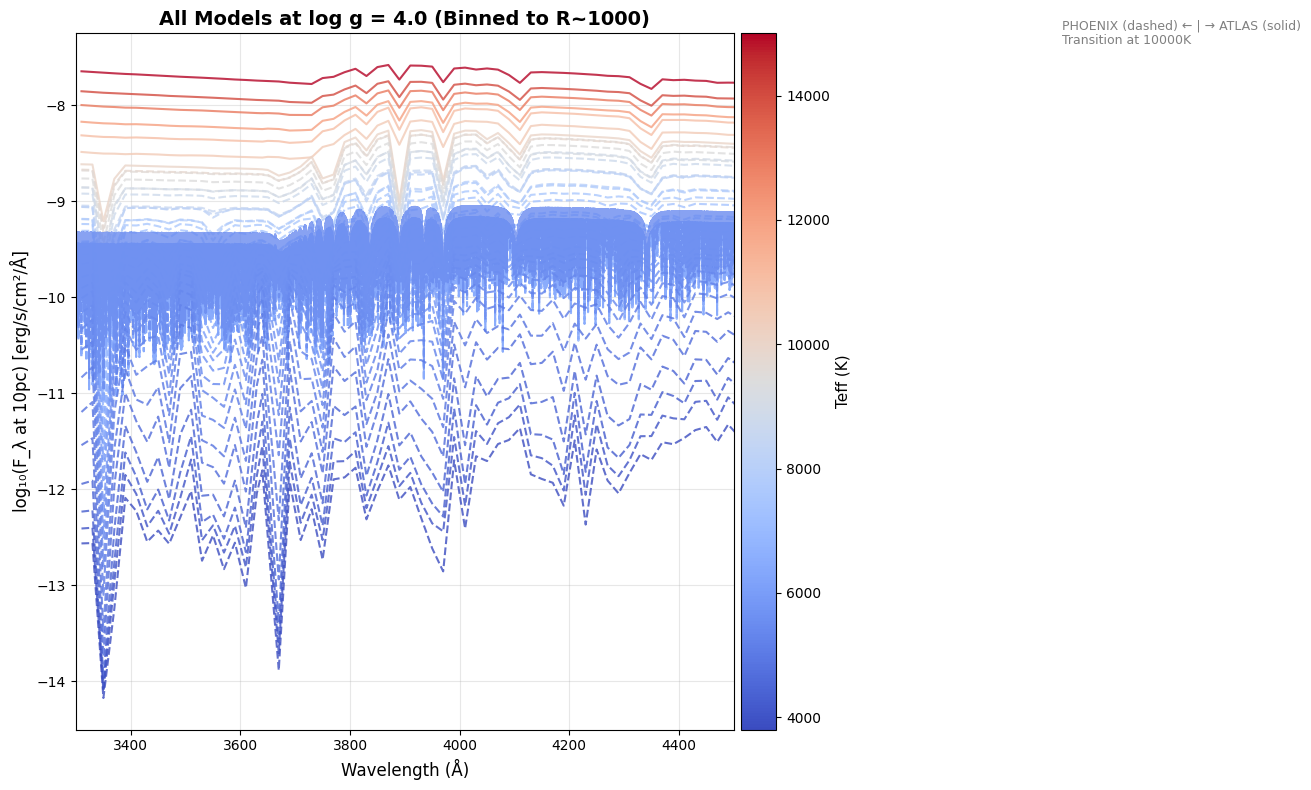


SPECTRUM SUMMARY:
  Teff (K)   Source   Points    λ_min    λ_max                       Filename
---------------------------------------------------------------------------
     15000    ATLAS      346   3310.0  10475.0    atlas-or-phoenix-150-40.txt
     14000    ATLAS      346   3310.0  10475.0    atlas-or-phoenix-140-40.txt
     13000    ATLAS      346   3310.0  10475.0    atlas-or-phoenix-130-40.txt
     12000    ATLAS      346   3310.0  10475.0    atlas-or-phoenix-120-40.txt
     11000    ATLAS      346   3310.0  10475.0    atlas-or-phoenix-110-40.txt
     10500    ATLAS      346   3310.0  10475.0    atlas-or-phoenix-105-40.txt
     10000    ATLAS      346   3310.0  10475.0    atlas-or-phoenix-100-40.txt
      9800  PHOENIX      346   3310.0  10475.0    atlas-or-phoenix-098-40.txt
      9600  PHOENIX      346   3310.0  10475.0    atlas-or-phoenix-096-40.txt
      9400  PHOENIX      346   3310.0  10475.0    atlas-or-phoenix-094-40.txt
      9200  PHOENIX      346   3310.0  10475.0 

In [18]:
# ============================================================================
# PLOT ALL logg=4.0 MODELS TO CHECK CONTINUITY
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.ndimage import uniform_filter1d
import numpy as np

print("Loading and plotting all logg=4.0 models...\n")

# Find all logg=4.0 models
model_files = sorted(OUTPUT_DIR.glob('*-40.txt'))

if len(model_files) == 0:
    print("No logg=4.0 models found!")
else:
    print(f"Found {len(model_files)} models with logg=4.0\n")
    
    # Parse Teff from filenames and sort by Teff (high to low)
    models = []
    for f in model_files:
        parts = f.stem.split('-')
        
        # Handle format: atlas-or-phoenix-TTT-40.txt (5 parts)
        if len(parts) == 5 and parts[0:3] == ['atlas', 'or', 'phoenix']:
            teff_code = parts[3]
            logg_code = parts[4]
            # Determine source from Teff
            teff = int(teff_code) * 100
            source = 'PHOENIX' if teff < 10000 else 'ATLAS'
            
        # Handle format: atlas-TTT-40.txt or phoenix-TTT-40.txt (3 parts)
        elif len(parts) == 3:
            source = parts[0].upper()
            teff_code = parts[1]
            logg_code = parts[2]
            teff = int(teff_code) * 100
        else:
            print(f"  Skipping {f.name}: unexpected format")
            continue
        
        # Load spectrum
        try:
            data = np.loadtxt(f)
            wave = data[:, 0]
            log_flux = data[:, 1]
            
            models.append({
                'teff': teff,
                'source': source,
                'wave': wave,
                'log_flux': log_flux,
                'file': f.name
            })
        except Exception as e:
            print(f"  Error loading {f.name}: {e}")
    
    if len(models) == 0:
        print("No valid models parsed!")
    else:
        # Sort by Teff (high to low)
        models = sorted(models, key=lambda x: x['teff'], reverse=True)
        
        print(f"Loaded {len(models)} models")
        print(f"Temperature range: {models[-1]['teff']}-{models[0]['teff']}K")
        print(f"  PHOENIX: {len([m for m in models if m['source']=='PHOENIX'])} models")
        print(f"  ATLAS: {len([m for m in models if m['source']=='ATLAS'])} models\n")
        
        # Bin to R~1000
        print("Binning spectra to R~1000...")
        
        def bin_to_resolution(wave, flux, target_R=1000):
            """Bin spectrum to target resolution using uniform smoothing"""
            smooth_window = 100
            flux_smooth = uniform_filter1d(flux, size=smooth_window, mode='nearest')
            downsample = 50
            wave_binned = wave[::downsample]
            flux_binned = flux_smooth[::downsample]
            #return wave_binned, flux_binned
            return wave, flux
        
        # Bin all spectra
        for m in models:
            m['wave_binned'], m['log_flux_binned'] = bin_to_resolution(
                m['wave'], m['log_flux'], target_R=1000
            )
        
        # Create color map
        teffs = [m['teff'] for m in models]
        cmap = cm.get_cmap('coolwarm')
        norm = plt.Normalize(vmin=min(teffs), vmax=max(teffs))
        
        # Plot
        fig, ax = plt.subplots(1, 1, figsize=(14, 8))
        
        for m in models:
            color = cmap(norm(m['teff']))
            linestyle = '-' if m['source'] == 'ATLAS' else '--'
            ax.plot(m['wave_binned'], m['log_flux_binned'], 
                    color=color, linewidth=1.5, alpha=0.8,
                    linestyle=linestyle)
        
        # Styling
        ax.set_xlabel('Wavelength (Å)', fontsize=12)
        ax.set_ylabel('log₁₀(F_λ at 10pc) [erg/s/cm²/Å]', fontsize=12)
        ax.set_title('All Models at log g = 4.0 (Binned to R~1000)', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(3300, 4500)
        
        # Color bar
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, pad=0.01)
        cbar.set_label('Teff (K)', fontsize=11)
        
        # Mark transition at 10000K
        ax.axvline(x=5000, color='gray', linestyle=':', linewidth=2, alpha=0.5)
        ax.text(5100, ax.get_ylim()[1]*0.98, 
                'PHOENIX (dashed) ← | → ATLAS (solid)\nTransition at 10000K', 
                fontsize=9, color='gray', va='top')
        
        plt.tight_layout()
        plt.show()
        
        # Print summary
        print(f"\n{'='*75}")
        print("SPECTRUM SUMMARY:")
        print(f"{'='*75}")
        print(f"{'Teff (K)':>10s} {'Source':>8s} {'Points':>8s} {'λ_min':>8s} {'λ_max':>8s} {'Filename':>30s}")
        print("-" * 75)
        
        for m in models:
            print(f"{m['teff']:10d} {m['source']:>8s} {len(m['wave_binned']):8d} "
                  f"{m['wave_binned'].min():8.1f} {m['wave_binned'].max():8.1f} "
                  f"{m['file']:>30s}")
        
        print(f"\n✓ Check for discontinuities at 10000K boundary!")
        print(f"  PHOENIX models (Teff < 10000K) shown as DASHED lines")
        print(f"  ATLAS models (Teff ≥ 10000K) shown as SOLID lines")